# NB13e: NB11 Baseline vs Tuned Comparison (v1)

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.


Reads NB11 hyperparameter-tuning results from `OUTPUTS_DIR / NB11_V2 / best_params / *.json`
and the global ResultRegistry. Pairs each tuned experiment with its source baseline by
`(parquet_name, classifier-family, cell_id)` and computes the head-to-head comparison.

**Question this answers:** which experiments benefited materially from tuning, on which metric, and is the lift robust across cities (mean(folds)) or just inflated by the dominant city (pooled OOF)?

**Outputs:**
- `cell_m1/M1_pairings.csv`           -- baseline-tuned pairs with delta_auc, delta_mean_folds
- `cell_m2/M2_delta_by_parquet.csv`   -- ranked by delta_mean_folds
- `cell_m3/M3_fold_aucs_wide.csv`     -- per-fold AUCs side-by-side (where available)
- `cell_m4/M4_pooled_vs_meanfolds_gap.csv`
- `cell_m5/M5_per_city_change.csv`    -- which cities improved most
- `cell_m6/M6_kappa_baseline_tuned.csv` -- prediction-set agreement
- `cell_m7/summary.json`

## CELL 1 -- CONFIG + GLOBAL SETUP

In [1]:
# @title CELL 1: NB11e CONFIG + GLOBAL SETUP
TIER_SELECTION = [0, 1, 2]
CITY_SELECTION = None
REQUIRE_UNOSAT = True

import platform, os
if platform.system() == "Windows":
    _setup = r"F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py"
elif os.path.exists("/content/drive_f"):
    _setup = "/content/drive_f/masterthesis/notebooks/global_setup.py"
else:
    _setup = "/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py"
with open(_setup) as f:
    exec(f.read())

OUT_DIR = RESULTS_ROOT / 'nb11e'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# NB11 hyperparameter results location
NB11_V2_DIR        = OUTPUTS_DIR / 'NB11_V2'
NB11_BEST_PARAMS   = NB11_V2_DIR / 'best_params'
NB11_OOF_DIR       = NB11_V2_DIR / 'oof'

from datetime import datetime as _dt
import pandas as pd
import numpy as np
import json as _json
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

import sys
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

from bda_results import ResultRegistry

print(f"  OUT_DIR:           {OUT_DIR}")
print(f"  NB11_V2_DIR:       {NB11_V2_DIR}")
print(f"  NB11_BEST_PARAMS:  {NB11_BEST_PARAMS}  exists={NB11_BEST_PARAMS.exists()}")
print(f"  NB11_OOF_DIR:      {NB11_OOF_DIR}  exists={NB11_OOF_DIR.exists()}")
print(f"  REGISTRY_DIR:      {RESULTS_ROOT / 'registry'}")


BDA GLOBAL SETUP
Started: 2026-07-03 08:44:03
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------


/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: True
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:564: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     930.7/7452.0 GB (6521.3 GB free)
  GDrive (F:)     1405.7/3726.0 GB (2320.3 GB free)
  Local data      11563.4/14901.9 GB (3338.4 GB free)
  Data stack      1405.7/3726.0 GB (2320.3 GB free)
  WSL ext4        69.1/1006.9 GB (886.6 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

## CELL S0 -- LOAD REGISTRY + NB11 BEST_PARAMS + HELPERS

In [2]:
# @title CELL S0: LOAD REGISTRY + NB11 BEST_PARAMS JSON + PAIRING HELPERS
print("=" * 70)
print("CELL S0: LOAD REGISTRY + NB11 BEST_PARAMS")
print("=" * 70)

# --- ResultRegistry (all baseline + tuned experiments) ---------------
experiments, profiles = ResultRegistry.load_all(RESULTS_ROOT)
EXPERIMENTS_DF = ResultRegistry.experiments_to_dataframe(experiments)
PER_CITY_DF = ResultRegistry.per_city_to_dataframe(experiments)
print(f"  EXPERIMENTS_DF: {len(EXPERIMENTS_DF)} rows")
print(f"  PER_CITY_DF:    {len(PER_CITY_DF)} rows")

# --- NB11 best_params JSON files (tuned-side source of truth) --------
BP_FILES = sorted(NB11_BEST_PARAMS.glob('*.json')) if NB11_BEST_PARAMS.exists() else []
print(f"  NB11 best_params JSON files: {len(BP_FILES)}")

NB11_TUNED = []     # list of dicts (one per tuned study)
for fp in BP_FILES:
    try:
        with open(fp) as f:
            d = _json.load(f)
        d['_path'] = str(fp)
        NB11_TUNED.append(d)
    except Exception as e:
        print(f"  WARN: could not load {fp.name}: {e}")

NB11_TUNED_DF = pd.DataFrame(NB11_TUNED) if NB11_TUNED else pd.DataFrame()
print(f"  NB11_TUNED_DF: {len(NB11_TUNED_DF)} tuned studies loaded")

# --- helpers ---------------------------------------------------------
def save_result(data, name, cell_id, fmt='csv'):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    if fmt == 'csv' and isinstance(data, pd.DataFrame):
        path = cell_dir / f"{name}_{ts}.csv"
        data.to_csv(path, index=False)
    elif fmt == 'json':
        path = cell_dir / f"{name}_{ts}.json"
        with open(path, 'w') as fh:
            _json.dump(data, fh, indent=2, default=str)
    else:
        raise ValueError(f"Unknown fmt={fmt}")
    print(f"  Saved: {path.relative_to(OUT_DIR)} ({path.stat().st_size / 1024:.1f} KB)")
    return path

import matplotlib.pyplot as plt

def save_fig(fig, name, cell_id, dpi=150, show=True):
    cell_dir = OUT_DIR / cell_id
    cell_dir.mkdir(parents=True, exist_ok=True)
    ts = _dt.now().strftime('%Y%m%d_%H%M%S')
    path = cell_dir / f"{name}_{ts}.png"
    fig.savefig(path, dpi=dpi, bbox_inches='tight', facecolor='white')
    if show:
        plt.show()
    print(f"  Plot: {path.relative_to(OUT_DIR)}")
    return path

# --- baseline finder -------------------------------------------------
def strip_optuna_suffix(clf_name):
    """LightGBM-MIA-Optuna -> LightGBM-MIA;  XGBoost-Optuna -> XGBoost"""
    if not isinstance(clf_name, str): return clf_name
    if clf_name.endswith('-Optuna'):
        return clf_name[:-len('-Optuna')]
    return clf_name

# Equivalence map from NB11-tuned classifier_name to source-baseline classifier_name.
# Source NB08c_v2 v8 baselines use 'LightGBM-300-MIA' (labelled, n_estimators=150 actually);
# NB11 logs tuned as 'LightGBM-MIA-Optuna'. So family-stem matching is needed.
TUNED_TO_BASELINE_FAMILY = {
    'LightGBM-MIA-Optuna':  ['LightGBM-300-MIA', 'LightGBM-MIA', 'LightGBM'],
    'LightGBM-Optuna':      ['LightGBM'],
    'XGBoost-Optuna':       ['XGBoost'],
    'RF-200-Optuna':        ['RF-200', 'RandomForest-200'],
    'ExtraTrees-Optuna':    ['ExtraTrees'],
    'GBM-Optuna':           ['GBM'],
}

def find_baseline_row(tuned_row, exp_df):
    """Find sibling baseline experiment in the registry. Returns Series or None."""
    pq = tuned_row.get('parquet_name')
    cell_id = tuned_row.get('cell_id')
    tuned_clf = tuned_row.get('classifier_name', '')
    feature_set = tuned_row.get('feature_set_name', None)

    candidate_clfs = TUNED_TO_BASELINE_FAMILY.get(tuned_clf, [strip_optuna_suffix(tuned_clf)])
    cand = exp_df[
        (exp_df['parquet_name'] == pq)
        & (exp_df['cell_id'] == cell_id)
        & (exp_df['classifier_name'].isin(candidate_clfs))
    ]
    if feature_set is not None and 'feature_set_name' in cand.columns:
        sub = cand[cand['feature_set_name'] == feature_set]
        if len(sub) > 0:
            cand = sub
    if len(cand) == 0:
        return None
    # Prefer the one with highest AUC (most recent / most relevant baseline)
    return cand.sort_values('auc', ascending=False).iloc[0]

print(f"\n  Helpers defined: save_result, save_fig, find_baseline_row")


CELL S0: LOAD REGISTRY + NB11 BEST_PARAMS
  Loaded: NB11_V2_experiments_20260703_083441.json (62 experiments, notebook=NB11_V2)
  Loaded: NB09b_experiments_20260628_003554.json (40 experiments, notebook=NB09b)
  Loaded: NB09c_v2_experiments_20260614_180054.json (74 experiments, notebook=NB09c_v2)
  Loaded: NB09d_experiments_20260621_232712.json (14 experiments, notebook=NB09d)
  Loaded: NB10a_v1_experiments_20260507_234428.json (6 experiments, notebook=NB10a_v1)
  Loaded: NB09aV3_v1_experiments_20260506_142934.json (47 experiments, notebook=NB09aV3_v1)
  Loaded: NB09aV5_v1_experiments_20260503_220957.json (47 experiments, notebook=NB09aV5_v1)
  Loaded: NB09aV4_v1_experiments_20260503_180614.json (47 experiments, notebook=NB09aV4_v1)
  Loaded: NB09a_v2_experiments_20260501_164920.json (44 experiments, notebook=NB09a_v2)
  Loaded: NB09eV3_v1_experiments_20260429_174010.json (18 experiments, notebook=NB09eV3_v1)
  Loaded: NB09cV3_v1_experiments_20260429_090246.json (48 experiments, notebo

## CELL M1 -- PAIRING TABLE

In [3]:
# @title CELL M1: PAIRING TABLE (baseline-tuned pairs)
print("=" * 70)
print("CELL M1: BUILD BASELINE-TUNED PAIRING TABLE")
print("=" * 70)

# Tuned rows: from registry (where classifier_name endswith '-Optuna' OR tags contain 'nb11_optuna')
if 'tags' in EXPERIMENTS_DF.columns:
    tuned_mask = (EXPERIMENTS_DF['classifier_name'].fillna('').str.endswith('-Optuna')
                  | EXPERIMENTS_DF['tags'].astype(str).str.contains('nb11_optuna', na=False))
else:
    tuned_mask = EXPERIMENTS_DF['classifier_name'].fillna('').str.endswith('-Optuna')

tuned_df = EXPERIMENTS_DF[tuned_mask].copy()
print(f"  Tuned registry rows: {len(tuned_df)}")

pairings = []
for _, t in tuned_df.iterrows():
    b = find_baseline_row(t, EXPERIMENTS_DF[~tuned_mask])
    if b is None:
        pairings.append({
            'notebook': t.get('notebook'),
            'parquet_name': t.get('parquet_name'),
            'cell_id': t.get('cell_id'),
            'tuned_classifier': t.get('classifier_name'),
            'baseline_classifier': None,
            'feature_set_name': t.get('feature_set_name'),
            'tuned_auc': t.get('auc'),
            'baseline_auc': None,
            'delta_auc': None,
            'tuned_experiment_name': t.get('experiment_name'),
            'baseline_experiment_name': None,
            'notes': 'no baseline sibling found',
        })
        continue
    delta_auc = (t.get('auc') - b.get('auc')) if pd.notna(t.get('auc')) and pd.notna(b.get('auc')) else None
    pairings.append({
        'notebook': t.get('notebook'),
        'parquet_name': t.get('parquet_name'),
        'cell_id': t.get('cell_id'),
        'tuned_classifier': t.get('classifier_name'),
        'baseline_classifier': b.get('classifier_name'),
        'feature_set_name': t.get('feature_set_name'),
        'tuned_auc': t.get('auc'),
        'baseline_auc': b.get('auc'),
        'delta_auc': delta_auc,
        'tuned_experiment_name': t.get('experiment_name'),
        'baseline_experiment_name': b.get('experiment_name'),
        'n_buildings': t.get('n_buildings'),
        'n_cities': t.get('n_cities'),
        'n_features': t.get('n_features'),
        'notes': None,
    })

PAIRINGS_DF = pd.DataFrame(pairings)
n_paired = int((PAIRINGS_DF['baseline_auc'].notna()).sum())
n_orphan = len(PAIRINGS_DF) - n_paired
print(f"  Paired: {n_paired}    Orphaned (no baseline sibling): {n_orphan}")

PAIRINGS_DF = PAIRINGS_DF.sort_values('delta_auc', ascending=False, na_position='last')
display(PAIRINGS_DF)
save_result(PAIRINGS_DF, 'M1_pairings', 'cell_m1')


CELL M1: BUILD BASELINE-TUNED PAIRING TABLE
  Tuned registry rows: 33
  Paired: 31    Orphaned (no baseline sibling): 2


,notebook,parquet_name,cell_id,tuned_classifier,baseline_classifier,feature_set_name,tuned_auc,baseline_auc,delta_auc,tuned_experiment_name,baseline_experiment_name,n_buildings,n_cities,n_features,notes
7,NB11_V2,bda_block_stats_v2,NB11e_dietrich28__block_stats__RF-200,RF-200-Optuna,RF-200,dietrich28,0.8452,0.6845,0.1607,NB11e_dietrich28__block_stats__RF-200,NB11e_dietrich28__block_stats__RF-200__baseline,598595.0000,21.0000,56.0000,NaN
0,NB11_V2,bda_block_stats_v2,NB11e_dietrich28__block_stats__LightGBM,LightGBM-Optuna,LightGBM,dietrich28,0.8652,0.8162,0.0490,NB11e_dietrich28__block_stats__LightGBM,NB11e_dietrich28__block_stats__LightGBM__baseline,598595.0000,21.0000,56.0000,NaN
16,NB11_V2,bda_fusion_composite_cohdrop_v2,NB11f_R3_sensor_ablations__fusion_composite_cohdrop__ms_...,RF-200-Optuna,RF-200,None,0.8187,0.7720,0.0467,NB11f_R3_sensor_ablations__fusion_composite_cohdrop__ms_...,NB11f_R3_sensor_ablations__fusion_composite_cohdrop__ms_...,466704.0000,18.0000,145.0000,NaN
20,NB11_V2,bda_fusion_composite_blockstats_v2,NB11f_R3_sensor_ablations__fusion_composite_blockstats__...,RF-200-Optuna,RF-200,None,0.8130,0.7737,0.0393,NB11f_R3_sensor_ablations__fusion_composite_blockstats__...,NB11f_R3_sensor_ablations__fusion_composite_blockstats__...,480313.0000,19.0000,915.0000,NaN
22,NB11_V2,bda_fusion_composite_blockstats_v2,NB11e_all_multimodal__fusion_composite_blockstats__RF-200,RF-200-Optuna,RF-200,all_multimodal,0.8129,0.7737,0.0392,NB11e_all_multimodal__fusion_composite_blockstats__RF-200,NB11e_all_multimodal__fusion_composite_blockstats__RF-20...,480313.0000,19.0000,915.0000,NaN
3,NB11_V2,bda_fusion_ms_cohdrop_v2,NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA,LightGBM-MIA-Optuna,LightGBM-MIA,None,0.8514,0.8126,0.0388,NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA,NB11a_F4_F7__fusion_ms_cohdrop__LightGBM-MIA__baseline,466704.0000,18.0000,88.0000,NaN
15,NB11_V2,bda_block_stats_v2,NB11f_R3_sensor_ablations__block_stats__card_block_stats...,RF-200-Optuna,RF-200,None,0.8210,0.7824,0.0386,NB11f_R3_sensor_ablations__block_stats__card_block_stats...,NB11f_R3_sensor_ablations__block_stats__card_block_stats...,598595.0000,21.0000,780.0000,NaN
11,NB11_V2,bda_fusion_composite_blockstats_v2,NB11a_F8__fusion_composite_blockstats__LightGBM-MIA,LightGBM-MIA-Optuna,LightGBM-MIA,None,0.8409,0.8050,0.0359,NB11a_F8__fusion_composite_blockstats__LightGBM-MIA,NB11a_F8__fusion_composite_blockstats__LightGBM-MIA__bas...,480313.0000,19.0000,915.0000,NaN
29,NB11_V2,bda_composite_prepost_bands_v2,NB11f_R3_sensor_ablations__composite_prepost_bands__ms_o...,RF-200-Optuna,RF-200,None,0.7937,0.7612,0.0324,NB11f_R3_sensor_ablations__composite_prepost_bands__ms_o...,NB11f_R3_sensor_ablations__composite_prepost_bands__ms_o...,480313.0000,19.0000,135.0000,NaN
28,NB11_V2,bda_composite_vs_scenes_bands_v2,NB11d_A11_A12_composite_vs_scenes__composite_vs_scenes_b...,LightGBM-MIA-Optuna,LightGBM-MIA,None,0.7955,0.7632,0.0323,NB11d_A11_A12_composite_vs_scenes__composite_vs_scenes_b...,NB11d_A11_A12_composite_vs_scenes__composite_vs_scenes_b...,438885.0000,16.0000,18.0000,NaN


  Saved: cell_m1/M1_pairings_20260703_084500.csv (10.6 KB)


PosixPath('/content/drive_f/masterthesis/results/nb11e/cell_m1/M1_pairings_20260703_084500.csv')

## CELL M2 -- DELTA PLOT + RANKED TABLE

CELL M2: RANKED DELTA TABLE + PLOTS
  Paired experiments: 31


,notebook,parquet_name,tuned_classifier,baseline_auc,tuned_auc,delta_auc,delta_mean_folds_auc,tuned_mean_folds_auc,tuned_std_folds_auc
0,NB11_V2,bda_block_stats_v2,RF-200-Optuna,0.6845,0.8452,0.1607,NaN,0.6434,0.1473
1,NB11_V2,bda_block_stats_v2,RF-200-Optuna,0.6845,0.8452,0.1607,NaN,0.7374,0.0880
2,NB11_V2,bda_block_stats_v2,RF-200-Optuna,0.6845,0.8452,0.1607,NaN,0.7451,0.0732
3,NB11_V2,bda_block_stats_v2,RF-200-Optuna,0.6845,0.8452,0.1607,NaN,0.7326,0.0898
4,NB11_V2,bda_block_stats_v2,RF-200-Optuna,0.6845,0.8452,0.1607,NaN,0.7443,0.0743
5,NB11_V2,bda_block_stats_v2,RF-200-Optuna,0.6845,0.8452,0.1607,NaN,0.7077,0.0713
6,NB11_V2,bda_block_stats_v2,LightGBM-Optuna,0.8162,0.8652,0.0490,NaN,0.6434,0.1473
7,NB11_V2,bda_block_stats_v2,LightGBM-Optuna,0.8162,0.8652,0.0490,NaN,0.7374,0.0880
8,NB11_V2,bda_block_stats_v2,LightGBM-Optuna,0.8162,0.8652,0.0490,NaN,0.7451,0.0732
9,NB11_V2,bda_block_stats_v2,LightGBM-Optuna,0.8162,0.8652,0.0490,NaN,0.7326,0.0898


  Saved: cell_m2/M2_delta_ranked_20260703_084500.csv (14.1 KB)


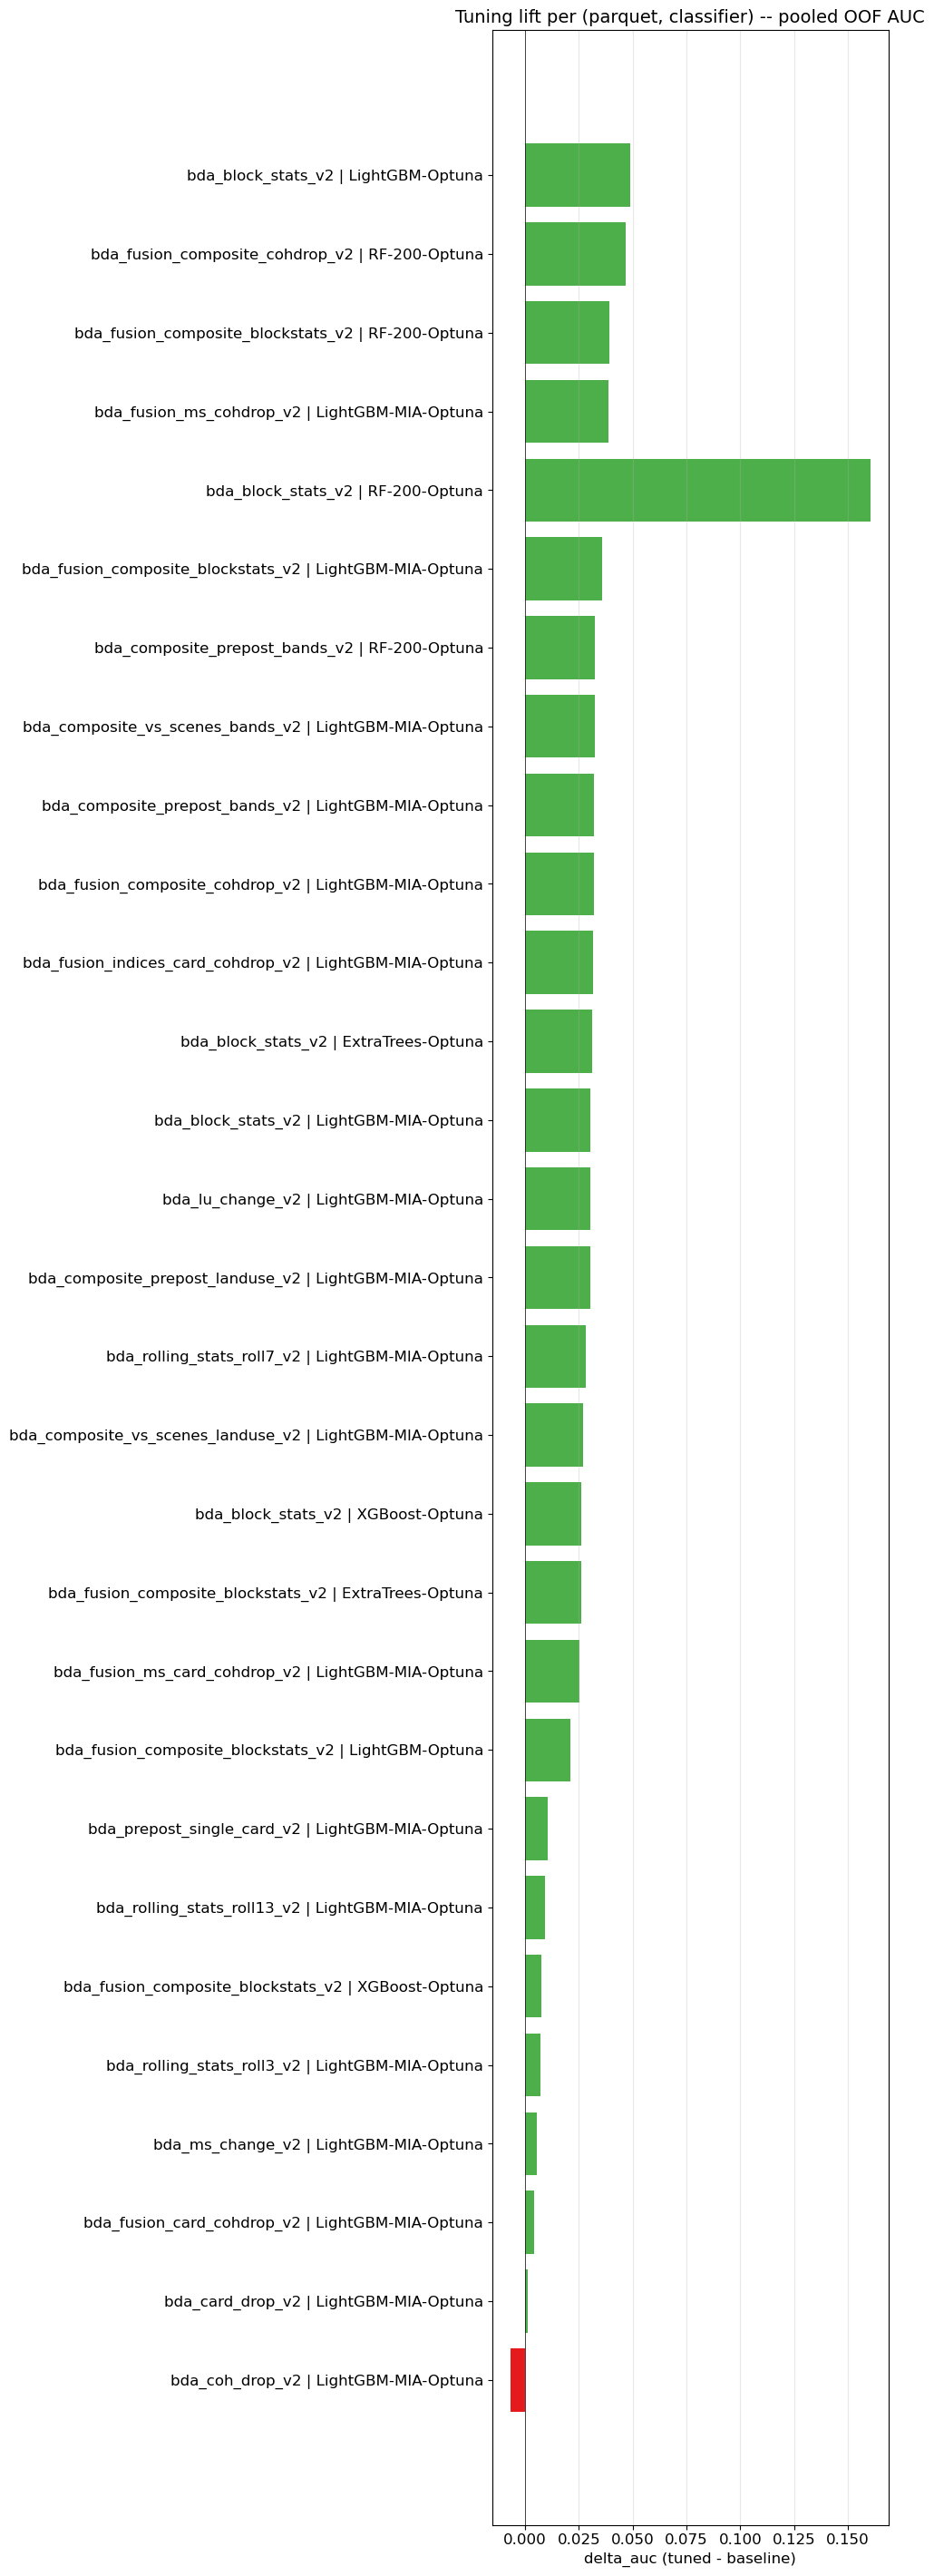

  Plot: cell_m2/M2_delta_auc_bar_20260703_084500.png


In [4]:
# @title CELL M2: DELTA PLOT + RANKED TABLE
print("=" * 70)
print("CELL M2: RANKED DELTA TABLE + PLOTS")
print("=" * 70)

paired = PAIRINGS_DF[PAIRINGS_DF['baseline_auc'].notna()].copy()
print(f"  Paired experiments: {len(paired)}")

# Use NB11_TUNED_DF for mean_folds_auc and std_folds_auc (registry note string is hard to parse)
# Match by parquet_name + tuned_classifier
if len(NB11_TUNED_DF) > 0:
    NB11_TUNED_DF['_parquet_name'] = 'bda_' + NB11_TUNED_DF['manifest_key'].astype(str) + '_v2'
    join_cols = ['_parquet_name']
    merge_cols = ['mean_folds_auc', 'std_folds_auc', 'fold_aucs',
                  'n_trials_done', 'n_trials_requested', 'delta_auc']
    available = [c for c in merge_cols if c in NB11_TUNED_DF.columns]
    paired = paired.merge(
        NB11_TUNED_DF[join_cols + available].rename(
            columns={'_parquet_name': 'parquet_name',
                     'mean_folds_auc': 'tuned_mean_folds_auc',
                     'std_folds_auc': 'tuned_std_folds_auc',
                     'fold_aucs': 'tuned_fold_aucs',
                     'n_trials_done': 'n_trials_done',
                     'n_trials_requested': 'n_trials_requested',
                     'delta_auc': 'delta_auc_from_json'}),
        on='parquet_name', how='left')

# Baseline mean_folds_auc: try from EXPERIMENTS_DF if column exists, else None
for _col in ['mean_folds_auc', 'auc_mean', 'fold_aucs']:
    if _col in EXPERIMENTS_DF.columns:
        baseline_lookup = EXPERIMENTS_DF.set_index('experiment_name')[_col].to_dict()
        paired[f'baseline_{_col}'] = paired['baseline_experiment_name'].map(baseline_lookup)

if 'tuned_mean_folds_auc' in paired.columns and 'baseline_mean_folds_auc' in paired.columns:
    paired['delta_mean_folds_auc'] = paired['tuned_mean_folds_auc'] - paired['baseline_mean_folds_auc']
elif 'tuned_mean_folds_auc' in paired.columns and 'baseline_auc_mean' in paired.columns:
    paired['delta_mean_folds_auc'] = paired['tuned_mean_folds_auc'] - paired['baseline_auc_mean']

# headline table
headline_cols = ['notebook', 'parquet_name', 'tuned_classifier',
                 'baseline_auc', 'tuned_auc', 'delta_auc',
                 'tuned_mean_folds_auc', 'tuned_std_folds_auc']
if 'delta_mean_folds_auc' in paired.columns:
    headline_cols.insert(headline_cols.index('tuned_mean_folds_auc'), 'delta_mean_folds_auc')
headline_cols = [c for c in headline_cols if c in paired.columns]

ranked = paired[headline_cols].sort_values('delta_auc', ascending=False)
display(ranked)
save_result(ranked, 'M2_delta_ranked', 'cell_m2')

# Plot: bar chart delta_auc per (parquet, classifier)
try:
    if len(paired) > 0:
        fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * len(paired))))
        ranked_for_plot = paired.sort_values('delta_auc', ascending=True)
        labels = ranked_for_plot.apply(
            lambda r: f"{r['parquet_name'][:35]} | {r['tuned_classifier']}", axis=1)
        colors = ['#4daf4a' if d > 0 else '#e41a1c' for d in ranked_for_plot['delta_auc']]
        ax.barh(labels, ranked_for_plot['delta_auc'], color=colors)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_xlabel('delta_auc (tuned - baseline)')
        ax.set_title('Tuning lift per (parquet, classifier) -- pooled OOF AUC')
        ax.grid(axis='x', alpha=0.3)
        fig.tight_layout()
        save_fig(fig, 'M2_delta_auc_bar', 'cell_m2')
        plt.close(fig)
except Exception as e:
    print(f"  Plot skipped: {e}")

paired_globals = paired   # cache for next cells


## CELL M3 -- PER-FOLD AUC COMPARISON

In [5]:
# @title CELL M3: PER-FOLD AUC COMPARISON (where available)
print("=" * 70)
print("CELL M3: PER-FOLD AUC COMPARISON")
print("=" * 70)

# tuned_fold_aucs is a list (from JSON); baseline fold_aucs may be in EXPERIMENTS_DF
# Build a long-form table: one row per (pair, fold_idx)
rows = []
for _, r in paired_globals.iterrows():
    pq = r.get('parquet_name')
    clf = r.get('tuned_classifier')
    tuned_folds = r.get('tuned_fold_aucs', None)
    if isinstance(tuned_folds, list):
        for fi, a in enumerate(tuned_folds):
            rows.append({'parquet_name': pq, 'classifier': clf,
                         'side': 'tuned', 'fold': fi, 'auc': a})
    baseline_folds = r.get('baseline_fold_aucs', None)
    if isinstance(baseline_folds, list):
        for fi, a in enumerate(baseline_folds):
            rows.append({'parquet_name': pq, 'classifier': clf,
                         'side': 'baseline', 'fold': fi, 'auc': a})

FOLD_AUCS_LONG = pd.DataFrame(rows)
if len(FOLD_AUCS_LONG) == 0:
    print("  No per-fold AUCs found (neither in tuned JSON nor in registry).")
else:
    FOLD_AUCS_WIDE = FOLD_AUCS_LONG.pivot_table(
        index=['parquet_name', 'classifier', 'fold'],
        columns='side', values='auc').reset_index()
    if 'baseline' in FOLD_AUCS_WIDE.columns and 'tuned' in FOLD_AUCS_WIDE.columns:
        FOLD_AUCS_WIDE['delta'] = FOLD_AUCS_WIDE['tuned'] - FOLD_AUCS_WIDE['baseline']
    display(FOLD_AUCS_WIDE)
    save_result(FOLD_AUCS_WIDE, 'M3_fold_aucs_wide', 'cell_m3')

    # Plot per-fold side-by-side for top N pairs by tuned AUC
    try:
        pairs_to_plot = paired_globals.sort_values('tuned_auc', ascending=False).head(8)
        if len(pairs_to_plot) > 0 and 'baseline' in FOLD_AUCS_WIDE.columns:
            fig, axes = plt.subplots(nrows=int(np.ceil(len(pairs_to_plot) / 2)),
                                     ncols=2, figsize=(12, 3 * max(1, int(np.ceil(len(pairs_to_plot)/2)))))
            axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
            for ax, (_, r) in zip(axes, pairs_to_plot.iterrows()):
                pq, clf = r['parquet_name'], r['tuned_classifier']
                sub = FOLD_AUCS_WIDE[(FOLD_AUCS_WIDE['parquet_name']==pq)
                                      & (FOLD_AUCS_WIDE['classifier']==clf)]
                if len(sub) == 0: continue
                x = np.arange(len(sub))
                w = 0.4
                if 'baseline' in sub.columns:
                    ax.bar(x - w/2, sub['baseline'], width=w, label='baseline', color='#999999')
                if 'tuned' in sub.columns:
                    ax.bar(x + w/2, sub['tuned'], width=w, label='tuned', color='#4daf4a')
                ax.set_title(f"{pq[:30]} | {clf}", fontsize=9)
                ax.set_xlabel('fold'); ax.set_ylabel('AUC')
                ax.set_xticks(x); ax.set_xticklabels(sub['fold'])
                ax.set_ylim(0.5, 1.0); ax.grid(alpha=0.3)
                ax.legend(fontsize=8)
            for ax in axes[len(pairs_to_plot):]:
                ax.axis('off')
            fig.tight_layout()
            save_fig(fig, 'M3_fold_aucs_comparison', 'cell_m3')
            plt.close(fig)
    except Exception as e:
        print(f"  Plot skipped: {e}")


CELL M3: PER-FOLD AUC COMPARISON


side,parquet_name,classifier,fold,tuned
0,bda_block_stats_v2,ExtraTrees-Optuna,0,0.6928
1,bda_block_stats_v2,ExtraTrees-Optuna,1,0.5927
2,bda_block_stats_v2,ExtraTrees-Optuna,2,0.7666
3,bda_block_stats_v2,ExtraTrees-Optuna,3,0.6842
4,bda_block_stats_v2,ExtraTrees-Optuna,4,0.8558
5,bda_block_stats_v2,LightGBM-MIA-Optuna,0,0.6928
6,bda_block_stats_v2,LightGBM-MIA-Optuna,1,0.5927
7,bda_block_stats_v2,LightGBM-MIA-Optuna,2,0.7666
8,bda_block_stats_v2,LightGBM-MIA-Optuna,3,0.6842
9,bda_block_stats_v2,LightGBM-MIA-Optuna,4,0.8558


  Saved: cell_m3/M3_fold_aucs_wide_20260703_084501.csv (9.4 KB)


## CELL M4 -- POOLED vs MEAN(FOLDS) GAP

In [6]:
# @title CELL M4: POOLED vs MEAN(FOLDS) GAP
print("=" * 70)
print("CELL M4: POOLED OOF vs MEAN(FOLDS) GAP")
print("=" * 70)

# For tuned: pooled = tuned_auc, mean_folds = tuned_mean_folds_auc
# For baseline: pooled = baseline_auc, mean_folds = baseline_mean_folds_auc (or auc_mean)
rows = []
for _, r in paired_globals.iterrows():
    pq, clf = r.get('parquet_name'), r.get('tuned_classifier')
    if pd.notna(r.get('tuned_auc')) and pd.notna(r.get('tuned_mean_folds_auc')):
        rows.append({'parquet_name': pq, 'classifier': clf, 'side': 'tuned',
                     'pooled': r['tuned_auc'], 'mean_folds': r['tuned_mean_folds_auc'],
                     'gap': r['tuned_auc'] - r['tuned_mean_folds_auc']})
    baseline_mean = r.get('baseline_mean_folds_auc') or r.get('baseline_auc_mean')
    if pd.notna(r.get('baseline_auc')) and pd.notna(baseline_mean):
        rows.append({'parquet_name': pq, 'classifier': clf, 'side': 'baseline',
                     'pooled': r['baseline_auc'], 'mean_folds': baseline_mean,
                     'gap': r['baseline_auc'] - baseline_mean})

GAP_DF = pd.DataFrame(rows)
if len(GAP_DF) > 0:
    display(GAP_DF.sort_values('gap', ascending=False))
    save_result(GAP_DF, 'M4_pooled_vs_meanfolds_gap', 'cell_m4')
    print(f"\n  Mean gap (tuned):    {GAP_DF[GAP_DF['side']=='tuned']['gap'].mean():.4f}")
    print(f"  Mean gap (baseline): {GAP_DF[GAP_DF['side']=='baseline']['gap'].mean():.4f}  (NaN if no baseline mean_folds available)")
else:
    print("  Insufficient data (need both pooled AUC and mean_folds_auc per side).")


CELL M4: POOLED OOF vs MEAN(FOLDS) GAP


,parquet_name,classifier,side,pooled,mean_folds,gap
94,bda_coh_drop_v2,LightGBM-MIA-Optuna,tuned,0.8005,0.5372,0.2633
91,bda_ms_change_v2,LightGBM-MIA-Optuna,tuned,0.7862,0.5421,0.2441
6,bda_block_stats_v2,LightGBM-Optuna,tuned,0.8652,0.6434,0.2218
63,bda_block_stats_v2,XGBoost-Optuna,tuned,0.8565,0.6434,0.2131
53,bda_block_stats_v2,LightGBM-MIA-Optuna,tuned,0.8531,0.6434,0.2097
0,bda_block_stats_v2,RF-200-Optuna,tuned,0.8452,0.6434,0.2017
47,bda_block_stats_v2,ExtraTrees-Optuna,tuned,0.8422,0.6434,0.1987
61,bda_rolling_stats_roll7_v2,LightGBM-MIA-Optuna,tuned,0.8514,0.6570,0.1944
93,bda_card_drop_v2,LightGBM-MIA-Optuna,tuned,0.8037,0.6154,0.1883
62,bda_composite_vs_scenes_landuse_v2,LightGBM-MIA-Optuna,tuned,0.8120,0.6238,0.1882


  Saved: cell_m4/M4_pooled_vs_meanfolds_gap_20260703_084501.csv (10.0 KB)

  Mean gap (tuned):    0.1239
  Mean gap (baseline): nan  (NaN if no baseline mean_folds available)


## CELL M5 -- PER-CITY AUC CHANGE

In [7]:
# @title CELL M5: PER-CITY AUC CHANGE
print("=" * 70)
print("CELL M5: PER-CITY AUC CHANGE (baseline -> tuned)")
print("=" * 70)

# Use PER_CITY_DF -- contains per_city AUC for every experiment that recorded it
if 'auc' not in PER_CITY_DF.columns or 'experiment_name' not in PER_CITY_DF.columns:
    print("  PER_CITY_DF missing required columns; skipping.")
else:
    rows = []
    for _, r in paired_globals.iterrows():
        t_name = r.get('tuned_experiment_name')
        b_name = r.get('baseline_experiment_name')
        if not (t_name and b_name): continue
        t_cities = PER_CITY_DF[PER_CITY_DF['experiment_name'] == t_name]
        b_cities = PER_CITY_DF[PER_CITY_DF['experiment_name'] == b_name]
        if len(t_cities) == 0 or len(b_cities) == 0: continue
        merged = t_cities[['city', 'auc']].rename(columns={'auc': 'tuned_auc'}).merge(
            b_cities[['city', 'auc']].rename(columns={'auc': 'baseline_auc'}),
            on='city', how='inner')
        for _, m in merged.iterrows():
            rows.append({
                'parquet_name': r['parquet_name'], 'classifier': r['tuned_classifier'],
                'city': m['city'], 'baseline_auc': m['baseline_auc'],
                'tuned_auc': m['tuned_auc'],
                'delta_auc': m['tuned_auc'] - m['baseline_auc'],
            })
    PER_CITY_CHANGE = pd.DataFrame(rows)
    if len(PER_CITY_CHANGE) > 0:
        agg = PER_CITY_CHANGE.groupby('city')['delta_auc'].agg(['mean', 'std', 'count']).reset_index()
        agg = agg.sort_values('mean', ascending=False)
        display(agg)
        save_result(PER_CITY_CHANGE, 'M5_per_city_change', 'cell_m5')
        save_result(agg, 'M5_per_city_change_agg', 'cell_m5')
    else:
        print("  No per-city overlap between baseline and tuned (run baseline experiments through PER_CITY logging).")


CELL M5: PER-CITY AUC CHANGE (baseline -> tuned)
  No per-city overlap between baseline and tuned (run baseline experiments through PER_CITY logging).


## CELL M6 -- COHEN'S KAPPA (BASELINE vs TUNED)

In [8]:
# @title CELL M6: PREDICTION-SET AGREEMENT (Cohen's kappa) at THR=0.5
print("=" * 70)
print("CELL M6: BASELINE vs TUNED COHEN'S KAPPA (where both OOF parquets exist)")
print("=" * 70)

# OOF parquet for tuned: NB11_OOF_DIR / oof_<model_id>__*.parquet
# OOF parquet for baseline: REGISTRY_DIR or NB08c_v2/NB09a output dirs (best-effort glob)
from sklearn.metrics import cohen_kappa_score

def _glob_oof_for(model_id, search_roots):
    pat = f"oof_*{model_id}*.parquet"
    found = []
    for root in search_roots:
        try:
            found.extend(Path(root).rglob(pat))
        except Exception:
            pass
    return sorted(found)

OOF_SEARCH_ROOTS = [RESULTS_ROOT, NB11_V2_DIR, OUTPUTS_DIR]

rows = []
for _, r in paired_globals.iterrows():
    t_name = r.get('tuned_experiment_name'); b_name = r.get('baseline_experiment_name')
    if not (t_name and b_name): continue
    t_files = _glob_oof_for(t_name, OOF_SEARCH_ROOTS)
    b_files = _glob_oof_for(b_name, OOF_SEARCH_ROOTS)
    if not t_files or not b_files: continue
    try:
        t_oof = pd.read_parquet(t_files[-1])   # latest by alphabetical (timestamp suffix)
        b_oof = pd.read_parquet(b_files[-1])
    except Exception as e:
        continue
    if 'building_id' not in t_oof.columns or 'building_id' not in b_oof.columns: continue
    # rename y_proba/y_pred consistent
    merged = t_oof[['building_id', 'y_proba']].rename(columns={'y_proba': 't_proba'}).merge(
        b_oof[['building_id', 'y_proba']].rename(columns={'y_proba': 'b_proba'}),
        on='building_id', how='inner')
    if len(merged) == 0: continue
    t_pred = (merged['t_proba'].values >= 0.5).astype(int)
    b_pred = (merged['b_proba'].values >= 0.5).astype(int)
    if len(np.unique(t_pred)) < 2 or len(np.unique(b_pred)) < 2:
        kap = float('nan')
    else:
        kap = cohen_kappa_score(b_pred, t_pred)
    rows.append({
        'parquet_name': r['parquet_name'], 'classifier': r['tuned_classifier'],
        'n_overlap': len(merged),
        'kappa_baseline_tuned_thr05': kap,
    })

KAPPA_DF = pd.DataFrame(rows)
if len(KAPPA_DF) > 0:
    KAPPA_DF = KAPPA_DF.sort_values('kappa_baseline_tuned_thr05', ascending=False)
    display(KAPPA_DF)
    save_result(KAPPA_DF, 'M6_kappa_baseline_tuned', 'cell_m6')
    print(f"\n  median kappa = {KAPPA_DF['kappa_baseline_tuned_thr05'].median():.4f}")
    print(f"  Low kappa => tuning moved many predictions; high kappa => same calls, different probabilities.")
else:
    print("  No baseline OOF parquets found alongside tuned OOFs. Cohen's kappa skipped.")


CELL M6: BASELINE vs TUNED COHEN'S KAPPA (where both OOF parquets exist)
  No baseline OOF parquets found alongside tuned OOFs. Cohen's kappa skipped.


## CELL M7 -- SUMMARY

In [9]:
# @title CELL M7: SUMMARY
print("=" * 70)
print("CELL M7: SUMMARY")
print("=" * 70)

summary = {
    'n_tuned_experiments_in_registry': int(len(tuned_df)),
    'n_paired_with_baseline': int((PAIRINGS_DF['baseline_auc'].notna()).sum()),
    'n_orphan_no_baseline': int((PAIRINGS_DF['baseline_auc'].isna()).sum()),
}
if (PAIRINGS_DF['delta_auc'].notna()).any():
    s = PAIRINGS_DF['delta_auc'].dropna()
    summary['delta_auc_pooled_mean']   = float(s.mean())
    summary['delta_auc_pooled_median'] = float(s.median())
    summary['delta_auc_pooled_min']    = float(s.min())
    summary['delta_auc_pooled_max']    = float(s.max())
    summary['n_positive_lift']         = int((s > 0).sum())
    summary['n_negative_lift']         = int((s < 0).sum())

if 'delta_mean_folds_auc' in paired_globals.columns:
    s = paired_globals['delta_mean_folds_auc'].dropna()
    if len(s) > 0:
        summary['delta_mean_folds_auc_mean']   = float(s.mean())
        summary['delta_mean_folds_auc_median'] = float(s.median())
        summary['n_positive_lift_mean_folds']  = int((s > 0).sum())

print(_json.dumps(summary, indent=2))
save_result(summary, 'summary', 'cell_m7', fmt='json')
print("\n  NB11e complete.")


CELL M7: SUMMARY
{
  "n_tuned_experiments_in_registry": 33,
  "n_paired_with_baseline": 31,
  "n_orphan_no_baseline": 2,
  "delta_auc_pooled_mean": 0.02974555034397947,
  "delta_auc_pooled_median": 0.03024485932233445,
  "delta_auc_pooled_min": -0.006989676527646815,
  "delta_auc_pooled_max": 0.16066299594257472,
  "n_positive_lift": 30,
  "n_negative_lift": 1
}
  Saved: cell_m7/summary_20260703_085108.json (0.3 KB)

  NB11e complete.
